# Rolling One-Day VaR Backtesting

This notebook turns the static risk measures from the previous stage into genuine one-day-ahead forecasts. It uses only information available before each forecast date, records strict VaR breaches, applies standard coverage and independence tests, and examines two fixed stress periods.

**Scope:** rolling Historical, Parametric Normal, and Monte Carlo Normal VaR/ES at 95% and 99%. This is a VaR backtesting study—not a trading strategy, stress test, or formal ES backtest.

## 1. Objective

The practical question is whether each model produces a sequence of risk forecasts whose exceptions are both appropriately frequent and independent through time. A model can have the right average exception count and still fail if exceptions arrive in clusters, which is especially important during fast regime changes.

The notebook preserves the Stage 1 return files and does not recompute returns from raw prices.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from PIL import Image
from scipy.special import xlogy
from scipy.stats import chi2, norm

WORKING_DIRECTORY = Path.cwd()
if (WORKING_DIRECTORY / "data" / "processed").exists():
    ROOT = WORKING_DIRECTORY
elif (WORKING_DIRECTORY.parent / "data" / "processed").exists():
    ROOT = WORKING_DIRECTORY.parent
else:
    raise RuntimeError(
        "Could not locate the project root from the current directory."
    )

DATA_DIR = ROOT / "data" / "processed"
TABLE_DIR = ROOT / "outputs" / "tables"
FIGURE_DIR = ROOT / "outputs" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ASSETS = ["SPY", "QQQ", "TLT", "GLD"]
WEIGHTS = pd.Series(
    {"SPY": 0.40, "QQQ": 0.25, "TLT": 0.20, "GLD": 0.15},
    name="Weight",
)
PORTFOLIO_VALUE = 1_000_000.0
WINDOW = 250
CONFIDENCE_LEVELS = (0.95, 0.99)
SIMULATIONS = 20_000
RANDOM_SEED = 42
QUANTILE_METHOD = "linear"
MODEL_PREFIXES = {
    "Historical": "Historical",
    "Parametric Normal": "Parametric_Normal",
    "Monte Carlo Normal": "Monte_Carlo_Normal",
}
STRESS_PERIODS = {
    "COVID-19 sell-off": (pd.Timestamp("2020-02-19"), pd.Timestamp("2020-04-30")),
    "2022 tightening": (pd.Timestamp("2022-01-03"), pd.Timestamp("2022-12-30")),
}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

print(f"Project root: {ROOT.relative_to(ROOT)}")
print(f"Rolling window: {WINDOW} observations")
print(f"Monte Carlo paths per forecast: {SIMULATIONS:,}; seed: {RANDOM_SEED}")

Project root: .
Rolling window: 250 observations
Monte Carlo paths per forecast: 20,000; seed: 42


## 2. Backtesting Design and No-Look-Ahead Rule

Returns are simple daily returns and loss is defined as

\[
L_t=-R_{p,t}.
\]

VaR and ES are positive one-trading-day loss measures. For forecast date \(t\), every model is fitted only on observations \(t-250,\ldots,t-1\). The realized loss on date \(t\) is used **only** after the forecast is made, for evaluation. The first 250 observations therefore initialize the models and the 251st observation is the first forecast date.

A breach is deliberately strict:

\[
I_t=\mathbf{1}\{L_t>\operatorname{VaR}_{t|t-1}\}.
\]

Equality is not a breach. Confidence levels are 95% and 99%, so the theoretical breach probabilities are 5% and 1% respectively. ES is forecast and used for severity context, but the formal statistical tests below apply only to VaR.

The portfolio is treated as a daily rebalanced constant-weight portfolio. Transaction costs, turnover, taxes, and implementation frictions are excluded.

## 3. Data Loading and Validation

The two processed CSV files are the controlling inputs. The checks below make their date grain, schema, alignment, ordering, uniqueness, missingness, and finiteness explicit before any model is fitted.

In [2]:
asset_returns = pd.read_csv(
    DATA_DIR / "asset_returns.csv",
    index_col="Date",
    parse_dates=["Date"],
)
portfolio_frame = pd.read_csv(
    DATA_DIR / "portfolio_returns.csv",
    index_col="Date",
    parse_dates=["Date"],
)

assert isinstance(asset_returns.index, pd.DatetimeIndex)
assert isinstance(portfolio_frame.index, pd.DatetimeIndex)
assert asset_returns.index.is_monotonic_increasing
assert portfolio_frame.index.is_monotonic_increasing
assert not asset_returns.index.has_duplicates
assert not portfolio_frame.index.has_duplicates
assert asset_returns.columns.tolist() == ASSETS
assert portfolio_frame.columns.tolist() == ["Portfolio"]
assert asset_returns.index.equals(portfolio_frame.index)
assert not asset_returns.isna().any().any()
assert not portfolio_frame.isna().any().any()
assert np.isfinite(asset_returns.to_numpy()).all()
assert np.isfinite(portfolio_frame.to_numpy()).all()
assert np.isclose(WEIGHTS.sum(), 1.0)
assert len(portfolio_frame) > WINDOW

portfolio_returns = portfolio_frame["Portfolio"].copy()

validation = pd.Series(
    {
        "Rows": len(portfolio_returns),
        "Sample start": portfolio_returns.index.min().date().isoformat(),
        "Sample end": portfolio_returns.index.max().date().isoformat(),
        "Asset columns": ", ".join(asset_returns.columns),
        "Portfolio column": portfolio_frame.columns[0],
        "Asset missing values": int(asset_returns.isna().sum().sum()),
        "Portfolio missing values": int(portfolio_frame.isna().sum().sum()),
        "Duplicate dates": int(portfolio_frame.index.duplicated().sum()),
        "Strictly increasing": bool(portfolio_frame.index.is_monotonic_increasing),
        "Weight sum": float(WEIGHTS.sum()),
    },
    name="Validated value",
)
display(validation.to_frame())

,Validated value
Rows,2190
Sample start,2018-01-03
Sample end,2026-09-21
Asset columns,"SPY, QQQ, TLT, GLD"
Portfolio column,Portfolio
Asset missing values,0
Portfolio missing values,0
Duplicate dates,0
Strictly increasing,True
Weight sum,1.000000


In [3]:
first_training = portfolio_returns.iloc[:WINDOW]
first_forecast_date = portfolio_returns.index[WINDOW]
expected_forecasts = len(portfolio_returns) - WINDOW

assert len(first_training) == WINDOW
assert first_training.index.max() < first_forecast_date

first_window_audit = pd.Series(
    {
        "Training start": first_training.index.min().date().isoformat(),
        "Training end": first_training.index.max().date().isoformat(),
        "Forecast date": first_forecast_date.date().isoformat(),
        "Training observations": len(first_training),
        "Expected forecast observations": expected_forecasts,
    },
    name="First forecast audit",
)
display(first_window_audit.to_frame())

,First forecast audit
Training start,2018-01-03
Training end,2018-12-31
Forecast date,2019-01-02
Training observations,250
Expected forecast observations,1940


## 4. Rolling Historical VaR and ES

Historical VaR is the empirical loss quantile from the preceding 250 observations. The implementation explicitly uses NumPy's `method="linear"` quantile rule. Historical ES is the mean of window losses satisfying `loss >= VaR`.

A 99% tail in a 250-day window contains only about 2.5 observations. Consequently, the 99% Historical estimate is discrete and sensitive to a few order statistics; linear quantile interpolation does not create additional tail evidence.

In [4]:
def rolling_historical(returns, window, confidence_levels, quantile_method):
    n_forecasts = len(returns) - window
    result = {}
    for confidence in confidence_levels:
        result[(confidence, "VaR")] = np.empty(n_forecasts)
        result[(confidence, "ES")] = np.empty(n_forecasts)

    for position in range(n_forecasts):
        window_returns = returns.iloc[position : position + window].to_numpy()
        window_losses = -window_returns
        for confidence in confidence_levels:
            var_value = np.quantile(
                window_losses,
                confidence,
                method=quantile_method,
            )
            es_value = window_losses[window_losses >= var_value].mean()
            result[(confidence, "VaR")][position] = var_value
            result[(confidence, "ES")][position] = es_value
    return result


historical = rolling_historical(
    portfolio_returns,
    WINDOW,
    CONFIDENCE_LEVELS,
    QUANTILE_METHOD,
)

historical_preview = pd.DataFrame(
    {
        f"Historical_{measure}_{int(confidence * 100)}": historical[(confidence, measure)]
        for confidence in CONFIDENCE_LEVELS
        for measure in ("VaR", "ES")
    },
    index=portfolio_returns.index[WINDOW:],
)
display(historical_preview.head())

,Historical_VaR_95,Historical_ES_95,Historical_VaR_99,Historical_ES_99
Date,,,,
2019-01-02,0.013691,0.018113,0.022789,0.024564
2019-01-03,0.013691,0.018113,0.022789,0.024564
2019-01-04,0.013907,0.018142,0.022789,0.024564
2019-01-07,0.013907,0.018142,0.022789,0.024564
2019-01-08,0.013907,0.018142,0.022789,0.024564


## 5. Rolling Parametric Normal VaR and ES

For each training window, let \(\mu_t\) be the sample mean return and \(s_t\) the sample standard deviation with `ddof=1`. With \(z_c=\Phi^{-1}(c)\), the positive-loss forecasts are

\[
\operatorname{VaR}_{c,t}
=
-\mu_t+s_tz_c,
\qquad
\operatorname{ES}_{c,t}
=
-\mu_t
+
s_t\frac{\phi(z_c)}{1-c}.
\]

No absolute-value correction is used: the signs follow directly from \(L=-R_p\). This model adapts as the rolling mean and volatility change, but it imposes a symmetric, thin-tailed Normal return distribution.

In [5]:
def rolling_parametric_normal(returns, window, confidence_levels):
    n_forecasts = len(returns) - window
    result = {}
    for confidence in confidence_levels:
        result[(confidence, "VaR")] = np.empty(n_forecasts)
        result[(confidence, "ES")] = np.empty(n_forecasts)

    for position in range(n_forecasts):
        window_values = returns.iloc[position : position + window].to_numpy()
        mean_return = window_values.mean()
        std_return = window_values.std(ddof=1)
        for confidence in confidence_levels:
            z_score = norm.ppf(confidence)
            result[(confidence, "VaR")][position] = -mean_return + std_return * z_score
            result[(confidence, "ES")][position] = (
                -mean_return
                + std_return * norm.pdf(z_score) / (1.0 - confidence)
            )
    return result


parametric = rolling_parametric_normal(
    portfolio_returns,
    WINDOW,
    CONFIDENCE_LEVELS,
)

parametric_preview = pd.DataFrame(
    {
        f"Parametric_Normal_{measure}_{int(confidence * 100)}": parametric[(confidence, measure)]
        for confidence in CONFIDENCE_LEVELS
        for measure in ("VaR", "ES")
    },
    index=portfolio_returns.index[WINDOW:],
)
display(parametric_preview.head())

,Parametric_Normal_VaR_95,Parametric_Normal_ES_95,Parametric_Normal_VaR_99,Parametric_Normal_ES_99
Date,,,,
2019-01-02,0.012625,0.015814,0.017825,0.020411
2019-01-03,0.012626,0.015812,0.017822,0.020406
2019-01-04,0.012774,0.015981,0.018004,0.020604
2019-01-07,0.012884,0.016134,0.018185,0.020821
2019-01-08,0.012881,0.016135,0.018188,0.020827


## 6. Rolling Monte Carlo Normal VaR and ES

Each forecast re-estimates the four-asset mean vector and covariance matrix from the preceding 250 observations. It then generates 20,000 joint one-day asset returns and applies the fixed 40%/25%/20%/15% weights.

The random number generator is `numpy.random.default_rng(42)`. One matrix of standard-Normal draws is reused across forecast windows as **common random numbers**. This preserves reproducibility and reduces irrelevant simulation noise when comparing dates; each window still applies its own newly estimated mean and covariance. Simulation is vectorized within each forecast date—there is no loop over individual paths.

The covariance matrix is symmetrized before Cholesky factorization. A disclosed diagonal repair is available only for tiny numerical non-positive eigenvalues; the notebook reports whether it was ever needed. Because this model and the Parametric Normal model share the same Normal-distribution assumption, similar forecasts are expected and do not validate either model.

In [6]:
def stable_cholesky(covariance):
    symmetric_covariance = (covariance + covariance.T) / 2.0
    assert np.allclose(
        symmetric_covariance,
        symmetric_covariance.T,
        rtol=0.0,
        atol=1e-14,
    )
    minimum_eigenvalue = float(np.linalg.eigvalsh(symmetric_covariance).min())
    numerical_floor = max(
        np.finfo(float).eps,
        float(np.diag(symmetric_covariance).max()) * 1e-12,
    )
    adjustment = max(0.0, numerical_floor - minimum_eigenvalue)
    if adjustment > 0.0:
        symmetric_covariance = (
            symmetric_covariance
            + np.eye(symmetric_covariance.shape[0]) * adjustment
        )
    factor = np.linalg.cholesky(symmetric_covariance)
    return factor, minimum_eigenvalue, adjustment


def rolling_monte_carlo_normal(
    returns,
    weights,
    window,
    confidence_levels,
    simulations,
    random_seed,
    quantile_method,
):
    n_forecasts = len(returns) - window
    result = {}
    for confidence in confidence_levels:
        result[(confidence, "VaR")] = np.empty(n_forecasts)
        result[(confidence, "ES")] = np.empty(n_forecasts)

    rng = np.random.default_rng(random_seed)
    standard_draws = rng.standard_normal((simulations, returns.shape[1]))
    minimum_eigenvalues = np.empty(n_forecasts)
    covariance_adjustments = np.zeros(n_forecasts)

    start_time = perf_counter()
    for position in range(n_forecasts):
        window_values = returns.iloc[position : position + window].to_numpy()
        mean_vector = window_values.mean(axis=0)
        covariance = np.cov(window_values, rowvar=False, ddof=1)
        factor, minimum_eigenvalue, adjustment = stable_cholesky(covariance)
        minimum_eigenvalues[position] = minimum_eigenvalue
        covariance_adjustments[position] = adjustment

        simulated_assets = mean_vector + np.einsum(
            "ij,kj->ki",
            factor,
            standard_draws,
            optimize=False,
        )
        simulated_portfolio_returns = np.sum(
            simulated_assets * weights.to_numpy(),
            axis=1,
        )
        simulated_losses = -simulated_portfolio_returns
        assert np.isfinite(simulated_losses).all()
        assert len(simulated_losses) == simulations

        for confidence in confidence_levels:
            var_value = np.quantile(
                simulated_losses,
                confidence,
                method=quantile_method,
            )
            es_value = simulated_losses[simulated_losses >= var_value].mean()
            result[(confidence, "VaR")][position] = var_value
            result[(confidence, "ES")][position] = es_value

    diagnostics = {
        "Runtime seconds": perf_counter() - start_time,
        "Forecast observations": n_forecasts,
        "Paths per forecast": simulations,
        "Minimum covariance eigenvalue": minimum_eigenvalues.min(),
        "PSD repair count": int((covariance_adjustments > 0.0).sum()),
        "Maximum diagonal repair": covariance_adjustments.max(),
    }
    return result, diagnostics


monte_carlo, monte_carlo_diagnostics = rolling_monte_carlo_normal(
    asset_returns[ASSETS],
    WEIGHTS[ASSETS],
    WINDOW,
    CONFIDENCE_LEVELS,
    SIMULATIONS,
    RANDOM_SEED,
    QUANTILE_METHOD,
)
display(pd.Series(monte_carlo_diagnostics, name="Monte Carlo diagnostic").to_frame())

,Monte Carlo diagnostic
Runtime seconds,1.282406
Forecast observations,"1,940.000000"
Paths per forecast,"20,000.000000"
Minimum covariance eigenvalue,0.000003
PSD repair count,0.000000
Maximum diagonal repair,0.000000


In [7]:
forecast_dates = portfolio_returns.index[WINDOW:]
forecast_table = pd.DataFrame(
    {
        "Date": forecast_dates,
        "Portfolio_Return": portfolio_returns.iloc[WINDOW:].to_numpy(),
        "Actual_Loss": -portfolio_returns.iloc[WINDOW:].to_numpy(),
    }
)

model_results = {
    "Historical": historical,
    "Parametric Normal": parametric,
    "Monte Carlo Normal": monte_carlo,
}
for model, prefix in MODEL_PREFIXES.items():
    for confidence in CONFIDENCE_LEVELS:
        level = int(confidence * 100)
        forecast_table[f"{prefix}_VaR_{level}"] = model_results[model][(confidence, "VaR")]
        forecast_table[f"{prefix}_ES_{level}"] = model_results[model][(confidence, "ES")]
        forecast_table[f"{prefix}_Breach_{level}"] = (
            forecast_table["Actual_Loss"]
            > forecast_table[f"{prefix}_VaR_{level}"]
        )

assert len(forecast_table) == expected_forecasts == 1_940
assert forecast_table["Date"].is_monotonic_increasing
assert not forecast_table["Date"].duplicated().any()
assert np.array_equal(
    forecast_table["Actual_Loss"].to_numpy(),
    -portfolio_returns.iloc[WINDOW:].to_numpy(),
)
assert not forecast_table.isna().any().any()

for model, prefix in MODEL_PREFIXES.items():
    assert (
        forecast_table[f"{prefix}_VaR_99"]
        >= forecast_table[f"{prefix}_VaR_95"] - 1e-15
    ).all()
    for level in (95, 99):
        var_column = f"{prefix}_VaR_{level}"
        es_column = f"{prefix}_ES_{level}"
        breach_column = f"{prefix}_Breach_{level}"
        assert np.isfinite(forecast_table[[var_column, es_column]].to_numpy()).all()
        assert (forecast_table[es_column] >= forecast_table[var_column] - 1e-15).all()
        assert np.array_equal(
            forecast_table[breach_column].to_numpy(),
            (forecast_table["Actual_Loss"] > forecast_table[var_column]).to_numpy(),
        )

rolling_forecast_path = TABLE_DIR / "rolling_var_forecasts.csv"
forecast_table.to_csv(rolling_forecast_path, index=False)
print(
    f"Saved {len(forecast_table):,} aligned forecasts to "
    f"{rolling_forecast_path.relative_to(ROOT)}"
)
display(forecast_table.head(3))

Saved 1,940 aligned forecasts to outputs/tables/rolling_var_forecasts.csv


,Date,Portfolio_Return,Actual_Loss,Historical_VaR_95,Historical_ES_95,Historical_Breach_95,Historical_VaR_99,Historical_ES_99,Historical_Breach_99,Parametric_Normal_VaR_95,Parametric_Normal_ES_95,Parametric_Normal_Breach_95,Parametric_Normal_VaR_99,Parametric_Normal_ES_99,Parametric_Normal_Breach_99,Monte_Carlo_Normal_VaR_95,Monte_Carlo_Normal_ES_95,Monte_Carlo_Normal_Breach_95,Monte_Carlo_Normal_VaR_99,Monte_Carlo_Normal_ES_99,Monte_Carlo_Normal_Breach_99
0,2019-01-02,0.002573,-0.002573,0.013691,0.018113,False,0.022789,0.024564,False,0.012625,0.015814,False,0.017825,0.020411,False,0.012578,0.015700,False,0.017805,0.020222,False
1,2019-01-03,-0.014077,0.014077,0.013691,0.018113,True,0.022789,0.024564,False,0.012626,0.015812,True,0.017822,0.020406,False,0.012581,0.015699,True,0.017799,0.020217,False
2,2019-01-04,0.020567,-0.020567,0.013907,0.018142,False,0.022789,0.024564,False,0.012774,0.015981,False,0.018004,0.020604,False,0.012730,0.015866,False,0.017971,0.020412,False


## 7. VaR Breach Analysis

The summary compares actual breaches with the theoretical rate and adds forecast magnitude and breach-severity measures. `Breach_Severity_Ratio` is the mean actual loss on breach dates divided by the model's mean VaR on those same dates. It is `NaN` by definition if a model has no breaches; this is not treated as missing source data.

In [8]:
summary_rows = []
for model, prefix in MODEL_PREFIXES.items():
    for confidence in CONFIDENCE_LEVELS:
        level = int(confidence * 100)
        var_column = f"{prefix}_VaR_{level}"
        es_column = f"{prefix}_ES_{level}"
        breach_column = f"{prefix}_Breach_{level}"
        breach_mask = forecast_table[breach_column]
        breach_count = int(breach_mask.sum())
        breach_losses = forecast_table.loc[breach_mask, "Actual_Loss"]
        breach_vars = forecast_table.loc[breach_mask, var_column]
        average_breach_loss = breach_losses.mean() if breach_count else np.nan
        average_breach_var = breach_vars.mean() if breach_count else np.nan

        summary_rows.append(
            {
                "Model": model,
                "Confidence_Level": confidence,
                "Forecast_Observations": len(forecast_table),
                "Expected_Breach_Probability": 1.0 - confidence,
                "Expected_Breach_Count": len(forecast_table) * (1.0 - confidence),
                "Actual_Breach_Count": breach_count,
                "Actual_Breach_Rate": breach_mask.mean(),
                "Breach_Count_Difference": breach_count - len(forecast_table) * (1.0 - confidence),
                "Average_VaR_Return": forecast_table[var_column].mean(),
                "Average_ES_Return": forecast_table[es_column].mean(),
                "Average_VaR_USD": forecast_table[var_column].mean() * PORTFOLIO_VALUE,
                "Average_ES_USD": forecast_table[es_column].mean() * PORTFOLIO_VALUE,
                "Max_Actual_Loss": forecast_table["Actual_Loss"].max(),
                "Average_Actual_Loss_on_Breach_Dates": average_breach_loss,
                "Max_Actual_Loss_on_Breach_Dates": breach_losses.max() if breach_count else np.nan,
                "Breach_Severity_Ratio": average_breach_loss / average_breach_var if breach_count else np.nan,
                "Portfolio_Value": PORTFOLIO_VALUE,
                "Holding_Period": "1 trading day",
                "Rolling_Window": WINDOW,
            }
        )

backtest_summary = pd.DataFrame(summary_rows)
backtest_summary_path = TABLE_DIR / "backtest_summary.csv"
backtest_summary.to_csv(backtest_summary_path, index=False)

summary_display = backtest_summary[
    [
        "Model",
        "Confidence_Level",
        "Expected_Breach_Count",
        "Actual_Breach_Count",
        "Actual_Breach_Rate",
        "Average_VaR_Return",
        "Average_ES_Return",
        "Breach_Severity_Ratio",
    ]
].copy()
display(summary_display)

,Model,Confidence_Level,Expected_Breach_Count,Actual_Breach_Count,Actual_Breach_Rate,Average_VaR_Return,Average_ES_Return,Breach_Severity_Ratio
0,Historical,0.950000,97.000000,110,0.056701,0.013198,0.019809,1.607588
1,Historical,0.990000,19.400000,28,0.014433,0.023968,0.029193,1.481454
2,Parametric Normal,0.950000,97.000000,98,0.050515,0.013723,0.017351,1.613278
3,Parametric Normal,0.990000,19.400000,45,0.023196,0.019640,0.022583,1.522403
4,Monte Carlo Normal,0.950000,97.000000,101,0.052062,0.013643,0.017204,1.605280
5,Monte Carlo Normal,0.990000,19.400000,46,0.023711,0.019419,0.022327,1.529962


## 8. Kupiec Unconditional Coverage Test

If \(x\) breaches occur in \(n\) forecasts, the observed breach probability is \(\hat p=x/n\) and the model-implied probability is \(p_0=1-c\). The likelihood-ratio statistic is

\[
LR_{uc}
=
-2\log\left[
\frac{(1-p_0)^{n-x}p_0^x}
{(1-\hat p)^{n-x}\hat p^x}
\right]
\sim\chi^2_1.
\]

## 9. Christoffersen Independence and Conditional Coverage Tests

Let \(n_{ij}\) count transitions from breach state \(i\) to state \(j\). The independence statistic compares one common transition probability with separate probabilities after non-breach and breach days:

\[
LR_{ind}
=
-2\log\left(
\frac{L(\hat\pi)}
{L(\hat\pi_{01},\hat\pi_{11})}
\right)
\sim\chi^2_1.
\]

Conditional coverage combines frequency and independence:

\[
LR_{cc}=LR_{uc}+LR_{ind}\sim\chi^2_2.
\]

`scipy.special.xlogy` makes terms such as \(0\log(0)\) well-defined. Empty transition-state denominators are handled explicitly. At the 5% significance level, `p < 0.05` is a mechanical rejection. A result with `p >= 0.05` means only that the sample does not provide sufficient evidence to reject the null; it does not prove that the model is correct.

In [9]:
def binomial_log_likelihood(successes, observations, probability):
    return float(
        xlogy(successes, probability)
        + xlogy(observations - successes, 1.0 - probability)
    )


def var_backtest_tests(breaches, confidence):
    breach_array = np.asarray(breaches, dtype=int)
    observations = len(breach_array)
    breach_count = int(breach_array.sum())
    expected_probability = 1.0 - confidence
    observed_probability = breach_count / observations

    null_log_likelihood = binomial_log_likelihood(
        breach_count,
        observations,
        expected_probability,
    )
    fitted_log_likelihood = binomial_log_likelihood(
        breach_count,
        observations,
        observed_probability,
    )
    lr_uc = max(0.0, 2.0 * (fitted_log_likelihood - null_log_likelihood))
    kupiec_p_value = chi2.sf(lr_uc, df=1)

    previous_state = breach_array[:-1]
    next_state = breach_array[1:]
    n00 = int(((previous_state == 0) & (next_state == 0)).sum())
    n01 = int(((previous_state == 0) & (next_state == 1)).sum())
    n10 = int(((previous_state == 1) & (next_state == 0)).sum())
    n11 = int(((previous_state == 1) & (next_state == 1)).sum())
    transition_count = observations - 1

    common_probability = (n01 + n11) / transition_count if transition_count else 0.0
    probability_after_zero = n01 / (n00 + n01) if (n00 + n01) else 0.0
    probability_after_one = n11 / (n10 + n11) if (n10 + n11) else 0.0

    independence_null_log_likelihood = binomial_log_likelihood(
        n01 + n11,
        transition_count,
        common_probability,
    )
    independence_fitted_log_likelihood = (
        binomial_log_likelihood(n01, n00 + n01, probability_after_zero)
        + binomial_log_likelihood(n11, n10 + n11, probability_after_one)
    )
    lr_ind = max(
        0.0,
        2.0 * (
            independence_fitted_log_likelihood
            - independence_null_log_likelihood
        ),
    )
    independence_p_value = chi2.sf(lr_ind, df=1)
    lr_cc = lr_uc + lr_ind
    conditional_coverage_p_value = chi2.sf(lr_cc, df=2)

    return {
        "Observations": observations,
        "Breach_Count": breach_count,
        "Breach_Rate": observed_probability,
        "Expected_Breach_Rate": expected_probability,
        "LR_uc": lr_uc,
        "Kupiec_p_value": kupiec_p_value,
        "Kupiec_Reject_5pct": bool(kupiec_p_value < 0.05),
        "N00": n00,
        "N01": n01,
        "N10": n10,
        "N11": n11,
        "LR_ind": lr_ind,
        "Christoffersen_Independence_p_value": independence_p_value,
        "Christoffersen_Independence_Reject_5pct": bool(independence_p_value < 0.05),
        "LR_cc": lr_cc,
        "Conditional_Coverage_p_value": conditional_coverage_p_value,
        "Conditional_Coverage_Reject_5pct": bool(conditional_coverage_p_value < 0.05),
    }


test_rows = []
for model, prefix in MODEL_PREFIXES.items():
    for confidence in CONFIDENCE_LEVELS:
        level = int(confidence * 100)
        test_result = var_backtest_tests(
            forecast_table[f"{prefix}_Breach_{level}"],
            confidence,
        )
        test_rows.append(
            {"Model": model, "Confidence_Level": confidence, **test_result}
        )

backtest_tests = pd.DataFrame(test_rows)
test_numeric_columns = [
    "LR_uc",
    "Kupiec_p_value",
    "LR_ind",
    "Christoffersen_Independence_p_value",
    "LR_cc",
    "Conditional_Coverage_p_value",
]
assert np.isfinite(backtest_tests[test_numeric_columns].to_numpy()).all()

backtest_tests_path = TABLE_DIR / "backtest_tests.csv"
backtest_tests.to_csv(backtest_tests_path, index=False)
display(backtest_tests)

,Model,Confidence_Level,Observations,Breach_Count,Breach_Rate,Expected_Breach_Rate,LR_uc,Kupiec_p_value,Kupiec_Reject_5pct,N00,N01,N10,N11,LR_ind,Christoffersen_Independence_p_value,Christoffersen_Independence_Reject_5pct,LR_cc,Conditional_Coverage_p_value,Conditional_Coverage_Reject_5pct
0,Historical,0.950000,1940,110,0.056701,0.050000,1.761180,0.184477,False,1727,102,102,8,0.517015,0.472118,False,2.278195,0.320108,False
1,Historical,0.990000,1940,28,0.014433,0.010000,3.386727,0.065723,False,1886,25,25,3,7.341400,0.006738,True,10.728127,0.004682,True
2,Parametric Normal,0.950000,1940,98,0.050515,0.050000,0.010817,0.917167,False,1749,92,92,6,0.231438,0.630459,False,0.242255,0.885921,False
3,Parametric Normal,0.990000,1940,45,0.023196,0.010000,24.867801,0.000001,True,1852,42,42,3,2.598720,0.106950,False,27.466522,0.000001,True
4,Monte Carlo Normal,0.950000,1940,101,0.052062,0.050000,0.171415,0.678858,False,1743,95,95,6,0.111024,0.738981,False,0.282439,0.868299,False
5,Monte Carlo Normal,0.990000,1940,46,0.023711,0.010000,26.600005,0.000000,True,1850,43,43,3,2.416680,0.120049,False,29.016684,0.000001,True


## 10. Stress-Period Analysis

The fixed periods below are labels for evaluating forecast behavior; they never enter model estimation:

- **COVID-19 sell-off:** 2020-02-19 through 2020-04-30
- **2022 tightening:** 2022-01-03 through 2022-12-30

`breach_details.csv` contains one row per model, confidence level, and strict breach, together with excess loss and severity. The worst-day table keeps all six model/level coverage indicators so failures cannot be hidden by aggregation.

In [10]:
def stress_label(date):
    for label, (start, end) in STRESS_PERIODS.items():
        if start <= date <= end:
            return label
    return "Other"


breach_detail_rows = []
for model, prefix in MODEL_PREFIXES.items():
    for confidence in CONFIDENCE_LEVELS:
        level = int(confidence * 100)
        var_column = f"{prefix}_VaR_{level}"
        es_column = f"{prefix}_ES_{level}"
        breach_column = f"{prefix}_Breach_{level}"
        breaches = forecast_table.loc[forecast_table[breach_column]].copy()
        for _, row in breaches.iterrows():
            breach_detail_rows.append(
                {
                    "Date": row["Date"],
                    "Portfolio_Return": row["Portfolio_Return"],
                    "Actual_Loss": row["Actual_Loss"],
                    "Model": model,
                    "Confidence_Level": confidence,
                    "Forecast_VaR": row[var_column],
                    "Forecast_ES": row[es_column],
                    "Loss_Minus_VaR": row["Actual_Loss"] - row[var_column],
                    "Loss_to_VaR_Ratio": row["Actual_Loss"] / row[var_column],
                    "Period": stress_label(row["Date"]),
                }
            )

breach_details = pd.DataFrame(breach_detail_rows).sort_values(
    ["Date", "Model", "Confidence_Level"]
)
breach_details_path = TABLE_DIR / "breach_details.csv"
breach_details.to_csv(breach_details_path, index=False)

stress_counts = (
    breach_details[breach_details["Period"] != "Other"]
    .groupby(["Period", "Model", "Confidence_Level"])
    .size()
    .rename("Breach_Count")
    .reset_index()
)

worst_dates = forecast_table.nlargest(10, "Actual_Loss")[
    ["Date", "Portfolio_Return", "Actual_Loss"]
].copy()
for model, prefix in MODEL_PREFIXES.items():
    for level in (95, 99):
        var_lookup = forecast_table.set_index("Date")[f"{prefix}_VaR_{level}"]
        worst_dates[f"{prefix}_Covered_{level}"] = (
            worst_dates["Actual_Loss"].to_numpy()
            <= worst_dates["Date"].map(var_lookup).to_numpy()
        )

display(Markdown("### Breaches in fixed stress periods"))
display(stress_counts)
display(Markdown("### Ten worst realized loss dates"))
display(worst_dates)
print(
    f"Saved {len(breach_details):,} breach-detail rows to "
    f"{breach_details_path.relative_to(ROOT)}"
)

### Breaches in fixed stress periods

,Period,Model,Confidence_Level,Breach_Count
0,2022 tightening,Historical,0.950000,31
1,2022 tightening,Historical,0.990000,9
2,2022 tightening,Monte Carlo Normal,0.950000,32
3,2022 tightening,Monte Carlo Normal,0.990000,16
4,2022 tightening,Parametric Normal,0.950000,31
5,2022 tightening,Parametric Normal,0.990000,16
6,COVID-19 sell-off,Historical,0.950000,14
7,COVID-19 sell-off,Historical,0.990000,8
8,COVID-19 sell-off,Monte Carlo Normal,0.950000,12
9,COVID-19 sell-off,Monte Carlo Normal,0.990000,8


### Ten worst realized loss dates

,Date,Portfolio_Return,Actual_Loss,Historical_Covered_95,Historical_Covered_99,Parametric_Normal_Covered_95,Parametric_Normal_Covered_99,Monte_Carlo_Normal_Covered_95,Monte_Carlo_Normal_Covered_99
300,2020-03-12,-0.065938,0.065938,False,False,False,False,False,False
302,2020-03-16,-0.062481,0.062481,False,False,False,False,False,False
297,2020-03-09,-0.042936,0.042936,False,False,False,False,False,False
304,2020-03-18,-0.042128,0.042128,False,False,False,False,False,False
1573,2025-04-04,-0.040276,0.040276,False,False,False,False,False,False
299,2020-03-11,-0.038282,0.038282,False,False,False,False,False,False
868,2022-06-13,-0.037049,0.037049,False,False,False,False,False,False
1572,2025-04-03,-0.033083,0.033083,False,False,False,False,False,False
842,2022-05-05,-0.032860,0.032860,False,False,False,False,False,False
363,2020-06-11,-0.032749,0.032749,False,True,False,False,False,False


Saved 428 breach-detail rows to outputs/tables/breach_details.csv


## 11. Model Comparison

The next four figures compare the time-varying limits and realized losses. Gains are clipped to zero **only in these plots** so the risk side remains legible; every breach and test uses the original signed loss series. Red points on the full-period charts identify dates when at least one model breached at that confidence level.

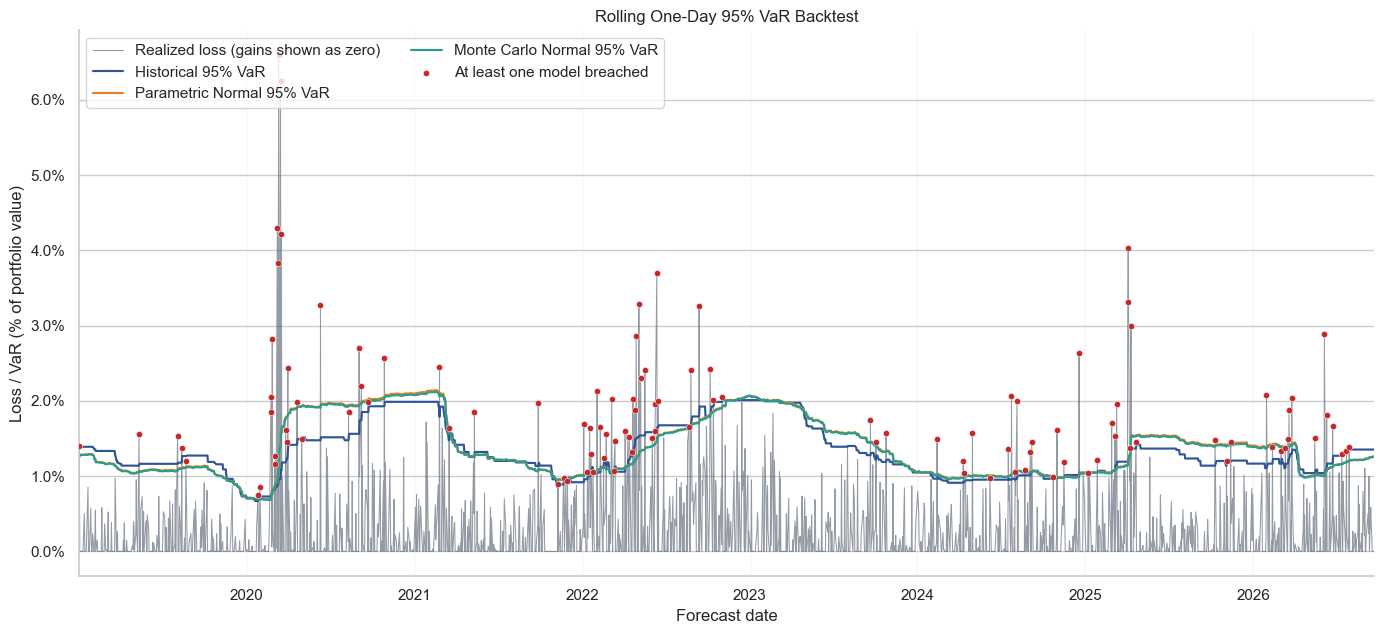

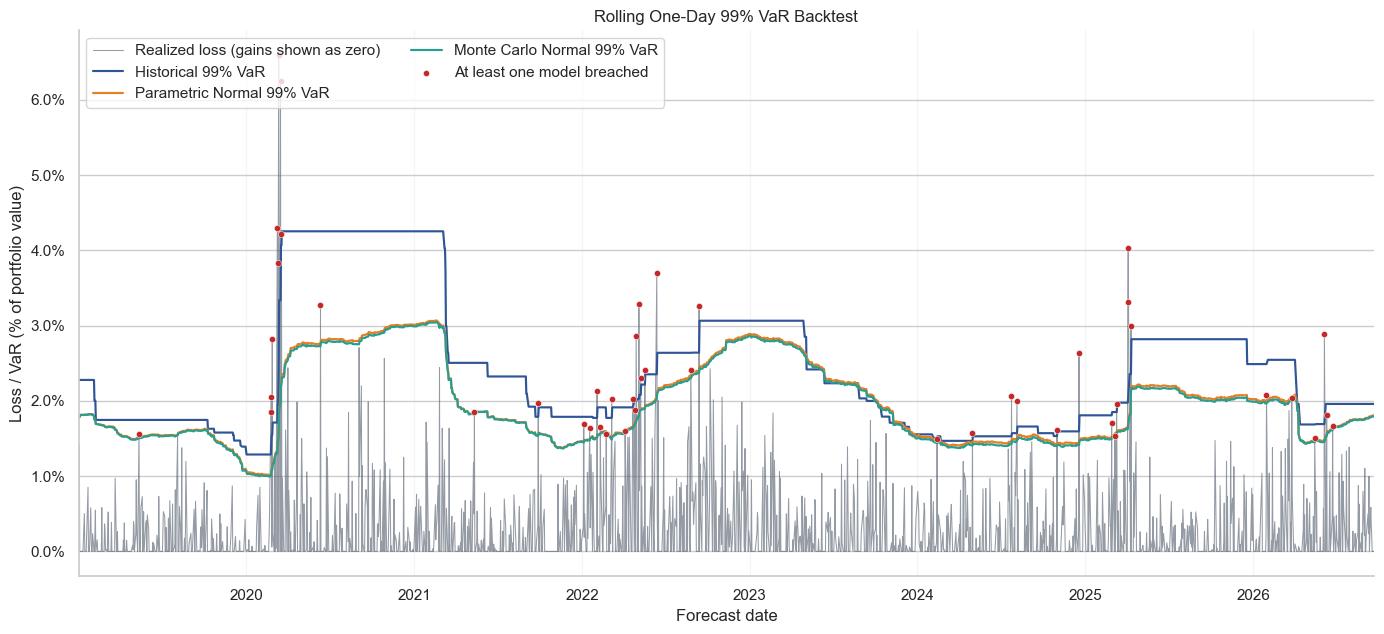

In [11]:
MODEL_COLORS = {
    "Historical": "#2F5597",
    "Parametric Normal": "#E67E22",
    "Monte Carlo Normal": "#2A9D8F",
}


def plot_rolling_backtest(confidence):
    level = int(confidence * 100)
    dates = forecast_table["Date"]
    plotted_losses = forecast_table["Actual_Loss"].clip(lower=0.0)
    any_breach = np.zeros(len(forecast_table), dtype=bool)

    fig, ax = plt.subplots(figsize=(14, 6.5))
    ax.plot(
        dates,
        plotted_losses,
        color="#5B6573",
        linewidth=0.75,
        alpha=0.65,
        label="Realized loss (gains shown as zero)",
    )
    for model, prefix in MODEL_PREFIXES.items():
        var_column = f"{prefix}_VaR_{level}"
        breach_column = f"{prefix}_Breach_{level}"
        any_breach |= forecast_table[breach_column].to_numpy()
        ax.plot(
            dates,
            forecast_table[var_column],
            color=MODEL_COLORS[model],
            linewidth=1.55,
            label=f"{model} {level}% VaR",
        )

    ax.scatter(
        dates[any_breach],
        plotted_losses[any_breach],
        color="#C62828",
        s=20,
        marker="o",
        edgecolor="white",
        linewidth=0.35,
        zorder=5,
        label="At least one model breached",
    )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f"Rolling One-Day {level}% VaR Backtest")
    ax.set_xlabel("Forecast date")
    ax.set_ylabel("Loss / VaR (% of portfolio value)")
    ax.set_xlim(dates.min(), dates.max())
    ax.legend(loc="upper left", ncol=2, frameon=True)
    ax.grid(axis="x", alpha=0.18)
    sns.despine(ax=ax)
    fig.tight_layout()

    output_path = FIGURE_DIR / f"rolling_var_backtest_{level}.png"
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()
    return output_path


rolling_95_path = plot_rolling_backtest(0.95)
rolling_99_path = plot_rolling_backtest(0.99)

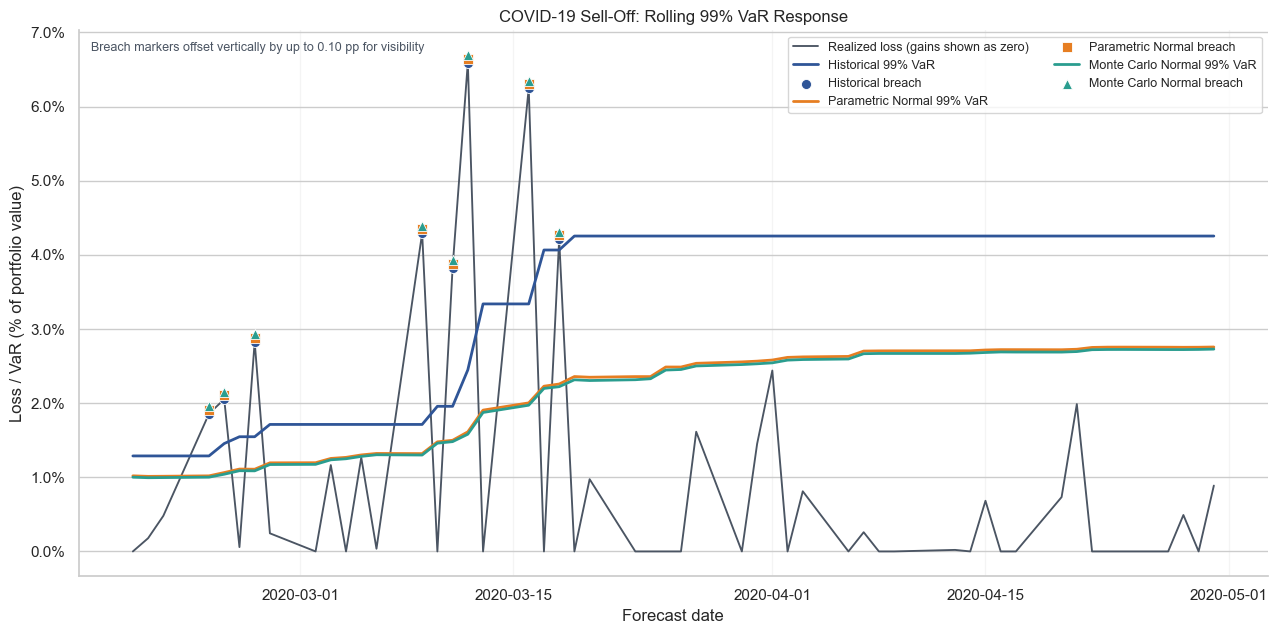

In [12]:
covid_start, covid_end = STRESS_PERIODS["COVID-19 sell-off"]
covid_mask = forecast_table["Date"].between(covid_start, covid_end)
covid_data = forecast_table.loc[covid_mask].copy()

fig, ax = plt.subplots(figsize=(13, 6.5))
covid_plot_losses = covid_data["Actual_Loss"].clip(lower=0.0)
ax.plot(
    covid_data["Date"],
    covid_plot_losses,
    color="#4B5563",
    linewidth=1.35,
    label="Realized loss (gains shown as zero)",
)

markers = {"Historical": "o", "Parametric Normal": "s", "Monte Carlo Normal": "^"}
marker_offsets = {
    "Historical": 0.0000,
    "Parametric Normal": 0.0005,
    "Monte Carlo Normal": 0.0010,
}
for model, prefix in MODEL_PREFIXES.items():
    var_column = f"{prefix}_VaR_99"
    breach_column = f"{prefix}_Breach_99"
    ax.plot(
        covid_data["Date"],
        covid_data[var_column],
        color=MODEL_COLORS[model],
        linewidth=2.0,
        label=f"{model} 99% VaR",
    )
    breach_mask = covid_data[breach_column]
    ax.scatter(
        covid_data.loc[breach_mask, "Date"],
        covid_plot_losses.loc[breach_mask] + marker_offsets[model],
        color=MODEL_COLORS[model],
        marker=markers[model],
        s=52,
        edgecolor="white",
        linewidth=0.6,
        zorder=6,
        label=f"{model} breach",
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("COVID-19 Sell-Off: Rolling 99% VaR Response")
ax.set_xlabel("Forecast date")
ax.set_ylabel("Loss / VaR (% of portfolio value)")
ax.text(
    0.01,
    0.98,
    "Breach markers offset vertically by up to 0.10 pp for visibility",
    transform=ax.transAxes,
    va="top",
    fontsize=9,
    color="#4B5563",
)
ax.legend(loc="upper right", ncol=2, fontsize=9, frameon=True)
ax.grid(axis="x", alpha=0.2)
sns.despine(ax=ax)
fig.tight_layout()

covid_figure_path = FIGURE_DIR / "covid_var_backtest_zoom.png"
fig.savefig(covid_figure_path, dpi=220, bbox_inches="tight")
plt.show()

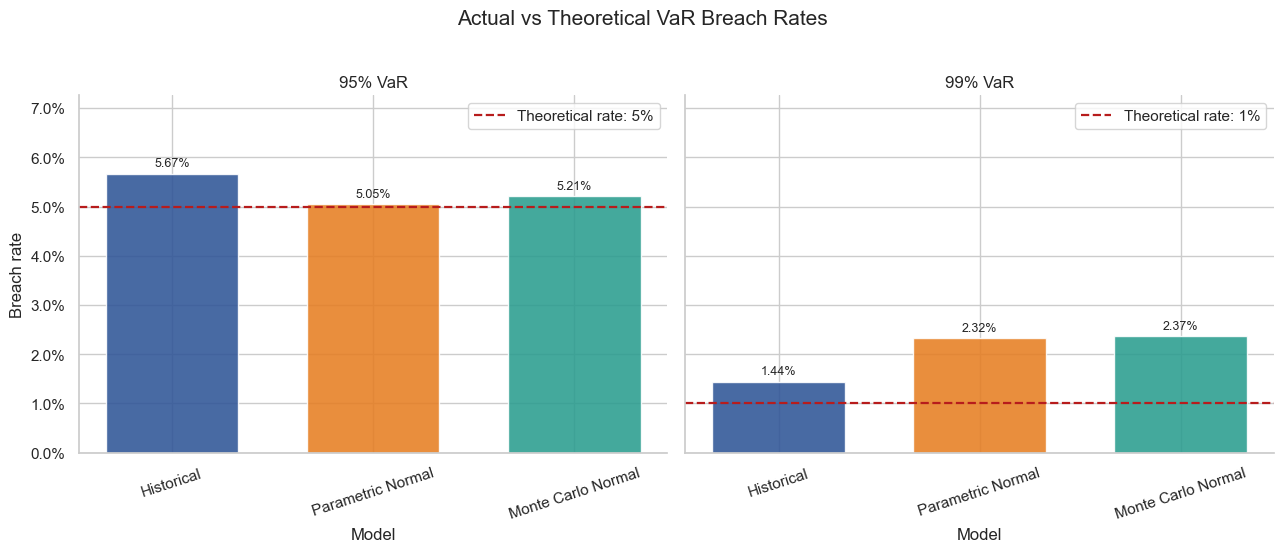

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharey=True)
model_order = list(MODEL_PREFIXES)
for ax, confidence in zip(axes, CONFIDENCE_LEVELS):
    subset = backtest_summary[
        backtest_summary["Confidence_Level"] == confidence
    ].set_index("Model").loc[model_order]
    colors = [MODEL_COLORS[model] for model in model_order]
    bars = ax.bar(
        model_order,
        subset["Actual_Breach_Rate"],
        color=colors,
        alpha=0.88,
        width=0.66,
    )
    target = 1.0 - confidence
    ax.axhline(
        target,
        color="#B71C1C",
        linestyle="--",
        linewidth=1.6,
        label=f"Theoretical rate: {target:.0%}",
    )
    ax.bar_label(
        bars,
        labels=[f"{value:.2%}" for value in subset["Actual_Breach_Rate"]],
        padding=3,
        fontsize=9,
    )
    ax.set_title(f"{confidence:.0%} VaR")
    ax.set_xlabel("Model")
    ax.tick_params(axis="x", rotation=18)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(loc="upper right", frameon=True)
    sns.despine(ax=ax)

axes[0].set_ylabel("Breach rate")
upper_limit = max(backtest_summary["Actual_Breach_Rate"].max() * 1.28, 0.065)
axes[0].set_ylim(0.0, upper_limit)
fig.suptitle("Actual vs Theoretical VaR Breach Rates", fontsize=15, y=1.02)
fig.tight_layout()

breach_rate_figure_path = FIGURE_DIR / "breach_rate_comparison.png"
fig.savefig(breach_rate_figure_path, dpi=220, bbox_inches="tight")
plt.show()

In [14]:
def decision_text(reject):
    return "reject" if bool(reject) else "do not reject"


closest_by_level = {}
for confidence in CONFIDENCE_LEVELS:
    level_summary = backtest_summary[
        backtest_summary["Confidence_Level"] == confidence
    ].copy()
    distance = (
        level_summary["Actual_Breach_Rate"] - (1.0 - confidence)
    ).abs()
    closest_row = level_summary.loc[distance.idxmin()]
    closest_by_level[confidence] = (
        closest_row["Model"],
        closest_row["Actual_Breach_Rate"],
    )

result_lines = []
for _, row in backtest_tests.iterrows():
    result_lines.append(
        f"- **{row['Model']}, {row['Confidence_Level']:.0%}:** "
        f"{int(row['Breach_Count'])} breaches ({row['Breach_Rate']:.2%}); "
        f"Kupiec p={row['Kupiec_p_value']:.4f} ({decision_text(row['Kupiec_Reject_5pct'])}); "
        f"independence p={row['Christoffersen_Independence_p_value']:.4f} "
        f"({decision_text(row['Christoffersen_Independence_Reject_5pct'])}); "
        f"conditional-coverage p={row['Conditional_Coverage_p_value']:.4f} "
        f"({decision_text(row['Conditional_Coverage_Reject_5pct'])})."
    )

stress_pivot = stress_counts.pivot_table(
    index=["Model", "Confidence_Level"],
    columns="Period",
    values="Breach_Count",
    fill_value=0,
)
worst_day = worst_dates.iloc[0]
normal_99 = backtest_summary[
    (backtest_summary["Confidence_Level"] == 0.99)
    & backtest_summary["Model"].isin(
        ["Parametric Normal", "Monte Carlo Normal"]
    )
].set_index("Model")

pre_covid = forecast_table["Date"].between("2020-01-22", "2020-02-18")
response_rows = []
response_dates = {}
for model, prefix in MODEL_PREFIXES.items():
    baseline = forecast_table.loc[pre_covid, f"{prefix}_VaR_99"].median()
    covid_peak_index = covid_data[f"{prefix}_VaR_99"].idxmax()
    covid_peak_date = covid_data.loc[covid_peak_index, "Date"]
    covid_peak = covid_data.loc[covid_peak_index, f"{prefix}_VaR_99"]
    threshold_hits = covid_data[
        covid_data[f"{prefix}_VaR_99"] >= 1.5 * baseline
    ]
    first_response_date = (
        threshold_hits["Date"].iloc[0] if not threshold_hits.empty else pd.NaT
    )
    response_dates[model] = first_response_date
    first_response = (
        first_response_date.date().isoformat()
        if pd.notna(first_response_date)
        else "not reached"
    )
    response_rows.append(
        f"- **{model}:** pre-COVID median 99% VaR {baseline:.2%}; "
        f"first reached 1.5× that level on {first_response}; "
        f"COVID-period peak {covid_peak:.2%} on {covid_peak_date.date().isoformat()}."
    )

display(
    Markdown(
        "### Test conclusions\n\n"
        + f"**Closest to the nominal rate:** {closest_by_level[0.95][0]} "
          f"at {closest_by_level[0.95][1]:.2%} was closest to 5%; "
          f"{closest_by_level[0.99][0]} at {closest_by_level[0.99][1]:.2%} "
          "was closest to 1%.\n\n"
        + "\n".join(result_lines)
        + "\n\n### Stress behavior and model response\n\n"
        + "\n".join(response_rows)
        + f"\n\nThe worst realized forecast-period loss was **{worst_day['Actual_Loss']:.2%}** "
          f"on **{worst_day['Date'].date().isoformat()}**. The coverage indicators in the "
          "worst-day table show directly which limits contained each event. During the initial "
          "COVID shock, all models lagged because every forecast was calibrated only to prior data; "
          "Historical VaR adjusts in steps as extremes enter the 250-day window, while the two Normal "
          "models respond through rolling covariance. Using the stated 1.5× pre-COVID VaR diagnostic, "
          f"Historical reacted on {response_dates['Historical'].date().isoformat()}, while both Normal "
          f"models reacted on {response_dates['Parametric Normal'].date().isoformat()}. Historical was "
          "therefore faster on this observable rule, although its stepwise behavior and eight 99% COVID "
          "breaches still demonstrate the path dependence of a 250-day window. In 2022, repeated "
          "exceptions indicate that a one-year window and static distributional form did not fully absorb "
          "the changing regime."
        + f"\n\nThe two Normal models recorded 99% breach rates of "
          f"{normal_99.loc['Parametric Normal', 'Actual_Breach_Rate']:.2%} and "
          f"{normal_99.loc['Monte Carlo Normal', 'Actual_Breach_Rate']:.2%}, both well above 1%, "
          "and both failed Kupiec and conditional coverage. This is empirical tail undercoverage; it is "
          "consistent with thin-tailed Normal assumptions but does not identify distributional form as the "
          "only cause. Monte Carlo Normal did not materially improve the Parametric Normal result because "
          "they share the same Normal assumption and produced almost identical rates and test decisions."
        + "\n\nAt 99%, consecutive-breach transitions (`N11`) are the clearest simple clustering diagnostic. "
          "The independence p-values determine whether that clustering is statistically rejected, while "
          "the charts retain the timing information that a single p-value cannot show."
    )
)

### Test conclusions

**Closest to the nominal rate:** Parametric Normal at 5.05% was closest to 5%; Historical at 1.44% was closest to 1%.

- **Historical, 95%:** 110 breaches (5.67%); Kupiec p=0.1845 (do not reject); independence p=0.4721 (do not reject); conditional-coverage p=0.3201 (do not reject).
- **Historical, 99%:** 28 breaches (1.44%); Kupiec p=0.0657 (do not reject); independence p=0.0067 (reject); conditional-coverage p=0.0047 (reject).
- **Parametric Normal, 95%:** 98 breaches (5.05%); Kupiec p=0.9172 (do not reject); independence p=0.6305 (do not reject); conditional-coverage p=0.8859 (do not reject).
- **Parametric Normal, 99%:** 45 breaches (2.32%); Kupiec p=0.0000 (reject); independence p=0.1070 (do not reject); conditional-coverage p=0.0000 (reject).
- **Monte Carlo Normal, 95%:** 101 breaches (5.21%); Kupiec p=0.6789 (do not reject); independence p=0.7390 (do not reject); conditional-coverage p=0.8683 (do not reject).
- **Monte Carlo Normal, 99%:** 46 breaches (2.37%); Kupiec p=0.0000 (reject); independence p=0.1200 (do not reject); conditional-coverage p=0.0000 (reject).

### Stress behavior and model response

- **Historical:** pre-COVID median 99% VaR 1.29%; first reached 1.5× that level on 2020-03-10; COVID-period peak 4.25% on 2020-03-19.
- **Parametric Normal:** pre-COVID median 99% VaR 1.02%; first reached 1.5× that level on 2020-03-12; COVID-period peak 2.76% on 2020-04-30.
- **Monte Carlo Normal:** pre-COVID median 99% VaR 1.01%; first reached 1.5× that level on 2020-03-12; COVID-period peak 2.73% on 2020-04-30.

The worst realized forecast-period loss was **6.59%** on **2020-03-12**. The coverage indicators in the worst-day table show directly which limits contained each event. During the initial COVID shock, all models lagged because every forecast was calibrated only to prior data; Historical VaR adjusts in steps as extremes enter the 250-day window, while the two Normal models respond through rolling covariance. Using the stated 1.5× pre-COVID VaR diagnostic, Historical reacted on 2020-03-10, while both Normal models reacted on 2020-03-12. Historical was therefore faster on this observable rule, although its stepwise behavior and eight 99% COVID breaches still demonstrate the path dependence of a 250-day window. In 2022, repeated exceptions indicate that a one-year window and static distributional form did not fully absorb the changing regime.

The two Normal models recorded 99% breach rates of 2.32% and 2.37%, both well above 1%, and both failed Kupiec and conditional coverage. This is empirical tail undercoverage; it is consistent with thin-tailed Normal assumptions but does not identify distributional form as the only cause. Monte Carlo Normal did not materially improve the Parametric Normal result because they share the same Normal assumption and produced almost identical rates and test decisions.

At 99%, consecutive-breach transitions (`N11`) are the clearest simple clustering diagnostic. The independence p-values determine whether that clustering is statistically rejected, while the charts retain the timing information that a single p-value cannot show.

## 12. Limitations and Risk-Management Implications

- A 250-day window is a practical convention, not an optimal or immutable horizon. It trades responsiveness against estimate stability.
- At 99% confidence, a 250-day Historical window contains only about 2–3 actual tail observations. Historical VaR is therefore discrete and sensitive to individual extremes.
- Historical ES here is the simple mean of observed losses at or beyond the linearly interpolated VaR threshold. This is clear and reproducible, but it is not an exact probability-weighted treatment of the interpolated boundary.
- Historical VaR can only recycle events in its window; rare losses enter abruptly and remain until they roll out.
- Parametric Normal and Monte Carlo Normal share the same thin-tailed, symmetric assumption. Monte Carlo adds a flexible simulation engine, but not a richer distribution in this implementation.
- Common random numbers improve date-to-date reproducibility; they do not reduce model risk.
- Kupiec and Christoffersen tests use asymptotic chi-square reference distributions. At 99% confidence, where breach counts are small, p-values and rejection decisions can be sensitive to finite-sample behavior.
- A result with `p >= 0.05` means there is not enough evidence to reject the null; it cannot prove that a model is correct.
- Fewer breaches than expected can indicate conservatism, but may also reflect a quiet evaluation sample or an overly high capital estimate. More breaches indicate undercoverage, but formal and economic materiality should be considered together.
- VaR says little about loss severity after the threshold is crossed. ES supplies that severity estimate, but this notebook does not claim a formal ES backtest.
- The portfolio is treated as a daily rebalanced constant-weight portfolio. Transaction costs, turnover, taxes, liquidity, nonlinear positions, intraday moves, and other implementation frictions are excluded.

In production, breach investigations should pair these tests with data controls, model-change governance, challenger models, scenario analysis, and explicit escalation thresholds.

## 13. Key Takeaways

The final cell performs reproducibility and artifact checks, then summarizes the empirical evidence. The key distinction is between **coverage frequency**, **breach independence**, and **tail severity**: no single number answers all three.

In [15]:
# Re-run a small Monte Carlo slice with the same seed to verify reproducibility.
verification_rng_1 = np.random.default_rng(RANDOM_SEED)
verification_rng_2 = np.random.default_rng(RANDOM_SEED)
assert np.array_equal(
    verification_rng_1.standard_normal((100, len(ASSETS))),
    verification_rng_2.standard_normal((100, len(ASSETS))),
)

output_tables = {
    "rolling forecasts": rolling_forecast_path,
    "backtest summary": backtest_summary_path,
    "backtest tests": backtest_tests_path,
    "breach details": breach_details_path,
}
reloaded_tables = {name: pd.read_csv(path) for name, path in output_tables.items()}
assert len(reloaded_tables["rolling forecasts"]) == expected_forecasts
assert len(reloaded_tables["backtest summary"]) == 6
assert len(reloaded_tables["backtest tests"]) == 6
assert len(reloaded_tables["breach details"]) == len(breach_details)

output_figures = [
    rolling_95_path,
    rolling_99_path,
    covid_figure_path,
    breach_rate_figure_path,
]
image_checks = []
for path in output_figures:
    with Image.open(path) as image:
        image.verify()
    with Image.open(path) as image:
        image_checks.append(
            {
                "File": path.name,
                "Width_px": image.width,
                "Height_px": image.height,
                "Mode": image.mode,
                "File_size_bytes": path.stat().st_size,
            }
        )

assert int(monte_carlo_diagnostics["Paths per forecast"]) == SIMULATIONS == 20_000
assert len(forecast_table) == len(portfolio_returns) - WINDOW
assert first_training.index.max() < first_forecast_date
assert (backtest_tests["Observations"] == expected_forecasts).all()
assert np.isfinite(backtest_tests[test_numeric_columns].to_numpy()).all()

print("All notebook validation checks passed.")
print(f"Forecast range: {forecast_table['Date'].min().date()} to {forecast_table['Date'].max().date()}")
print(f"Forecast observations: {len(forecast_table):,}")
print(f"Monte Carlo paths per forecast: {SIMULATIONS:,}")
print(f"PSD repairs used: {monte_carlo_diagnostics['PSD repair count']}")
display(pd.DataFrame(image_checks))

takeaway_rows = []
for _, row in backtest_summary.iterrows():
    tests = backtest_tests[
        (backtest_tests["Model"] == row["Model"])
        & (backtest_tests["Confidence_Level"] == row["Confidence_Level"])
    ].iloc[0]
    takeaway_rows.append(
        f"- **{row['Model']} at {row['Confidence_Level']:.0%}:** "
        f"{int(row['Actual_Breach_Count'])} breaches versus "
        f"{row['Expected_Breach_Count']:.1f} expected; "
        f"average VaR {row['Average_VaR_Return']:.2%}, average ES {row['Average_ES_Return']:.2%}; "
        f"Kupiec p={tests['Kupiec_p_value']:.4f}, "
        f"independence p={tests['Christoffersen_Independence_p_value']:.4f}, "
        f"conditional-coverage p={tests['Conditional_Coverage_p_value']:.4f}."
    )

display(
    Markdown(
        "### Evidence-based summary\n\n"
        + "\n".join(takeaway_rows)
        + "\n\nThe 95% results are close to their nominal frequency, but 99% behavior is the main model-risk concern. "
          "The test decisions, stress-period counts, and worst-day coverage should be reviewed together: "
          "a passing frequency test cannot rule out clustered exceptions, and a low breach count alone "
          "does not establish good calibration. The next stage may compare alternative windows or richer "
          "volatility and tail models, while keeping this notebook's strict no-look-ahead alignment as the baseline."
    )
)

All notebook validation checks passed.
Forecast range: 2019-01-02 to 2026-09-21
Forecast observations: 1,940
Monte Carlo paths per forecast: 20,000
PSD repairs used: 0


,File,Width_px,Height_px,Mode,File_size_bytes
0,rolling_var_backtest_95.png,3045,1396,RGBA,454568
1,rolling_var_backtest_99.png,3045,1396,RGBA,460883
2,covid_var_backtest_zoom.png,2812,1396,RGBA,290248
3,breach_rate_comparison.png,2825,1217,RGBA,126070


### Evidence-based summary

- **Historical at 95%:** 110 breaches versus 97.0 expected; average VaR 1.32%, average ES 1.98%; Kupiec p=0.1845, independence p=0.4721, conditional-coverage p=0.3201.
- **Historical at 99%:** 28 breaches versus 19.4 expected; average VaR 2.40%, average ES 2.92%; Kupiec p=0.0657, independence p=0.0067, conditional-coverage p=0.0047.
- **Parametric Normal at 95%:** 98 breaches versus 97.0 expected; average VaR 1.37%, average ES 1.74%; Kupiec p=0.9172, independence p=0.6305, conditional-coverage p=0.8859.
- **Parametric Normal at 99%:** 45 breaches versus 19.4 expected; average VaR 1.96%, average ES 2.26%; Kupiec p=0.0000, independence p=0.1070, conditional-coverage p=0.0000.
- **Monte Carlo Normal at 95%:** 101 breaches versus 97.0 expected; average VaR 1.36%, average ES 1.72%; Kupiec p=0.6789, independence p=0.7390, conditional-coverage p=0.8683.
- **Monte Carlo Normal at 99%:** 46 breaches versus 19.4 expected; average VaR 1.94%, average ES 2.23%; Kupiec p=0.0000, independence p=0.1200, conditional-coverage p=0.0000.

The 95% results are close to their nominal frequency, but 99% behavior is the main model-risk concern. The test decisions, stress-period counts, and worst-day coverage should be reviewed together: a passing frequency test cannot rule out clustered exceptions, and a low breach count alone does not establish good calibration. The next stage may compare alternative windows or richer volatility and tail models, while keeping this notebook's strict no-look-ahead alignment as the baseline.